In [ ]:
!CUDA_VISIBLE_DEVICES=2 nohup python train.py --stage 1 \
  --skeleton_folder /home/qsw26/smartfall/gait_loss/filtered_skeleton_data \
  --hip_folder /home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/phone \
  --wrist_folder /home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/watch \
  --train_subjects 29,30,31,32,35,36,37,38,39,43,44,45,46,49,51,56,57,58,59,61,62 \
  --batch_size 16 \
  --epochs 250 \
  --lr 1e-4 \
  --latent_dim 128 \
  --window 90 \
  --stride 45 \
  --save_dir new_checkpoints/stage1_gcnn_changed_edits_withreport_april3 \
  --report_dir /home/qsw26/smartfall/gait_loss/ldm_with_loss/reports/stage1 \
  --run_name stage1_gcnn_changed_edits_withreport_april3 


In [13]:
!CUDA_VISIBLE_DEVICES=2 python train.py --stage 2 \
  --stage1_ckpt new_checkpoints/stage1_gcnn_changed_edits_withreport_april3/stage1_best.pt \
  --skeleton_folder /home/qsw26/smartfall/gait_loss/filtered_skeleton_data \
  --hip_folder /home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/phone \
  --wrist_folder /home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/watch \
  --save_dir new_checkpoints/stage2_gcnn_changed_edits_withreport_april3_regularized_0.5_simple_12_24f \
  --train_subjects 29,30,31,32,35,36,37,38,39,43,44,45,46,49,51,56,57,58,59,61,62 \
  --batch_size 16 \
  --lambda_feature 1.0 \
  --stride 30 \
  --lambda_align 0.1 \
  --lambda_cls_s2 0.1 \
--lambda_gait_s2 1 \
  --stage2_dropout 0.5 \
  --stage2_weight_decay 0.003 \
  --stage2_aug_noise_std 0.01 \
  --stage2_aug_scale 0.05 \
  --stage2_aug_mask_prob 0.05 \
  --stage2_scheduler_patience 3 \
  --stage2_scheduler_factor 0.5 \
  --stage2_scheduler_min_lr 1e-6 \
  --latent_dim 128 \
  --epochs 250 \
  --report_dir /home/qsw26/smartfall/gait_loss/ldm_with_loss/reports/stage1 \
  --run_name stage2_gcnn_changed_edits_withreport_april3_regularized_0.5_simple_12_24f

2026-04-05 04:16:59.732040: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 04:17:01,678 | INFO | train | DDP enabled: False (world_size=1)
/home/qsw26/smartfall/gait_loss/ldm_with_loss/diffusion_model/model_loader.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer

In [14]:
!CUDA_VISIBLE_DEVICES=1 nohup python train.py \
  --stage 3 \
  --stage1_ckpt new_checkpoints/stage1_gcnn_changed_edits_withreport_april3/stage1_best.pt \
  --stage2_ckpt new_checkpoints/stage2_gcnn_changed_edits_withreport_april3_regularized_0.5_simple_12_24f/stage2_best.pt \
  --skeleton_folder /home/qsw26/smartfall/gait_loss/filtered_skeleton_data \
  --hip_folder /home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/phone \
  --wrist_folder /home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/watch \
  --train_subjects 29,30,31,32,35,36,37,38,39,43,44,45,46,49,51,56,57,58,59,61,62 \
  --gait_cache_dir outputs/gait_cache \
  --save_dir new_checkpoints/stage3_gcnn_changed_edits_withreport_april3_regularized_0.5_simple1224f \
  --batch_size 16 \
  --lr 1e-4 \
  --epochs 250 \
  --lambda_cls 0.1 \
  --lambda_pose 0.5 \
  --lambda_latent 0.5 \
  --lambda_vel 0.5 \
  --lambda_motion 1.0 \
  --lambda-gait 1 \
  --sampler ddpm \
  --latent_dim 128 \
  --eval_every_stage3 10 \
  --report_dir /home/qsw26/smartfall/gait_loss/ldm_with_loss/reports/stage3\
  --run_name stage3_gcnn_changed_edits_withreport_april3_regularized_0.5_simple1224f


nohup: ignoring input and appending output to 'nohup.out'


In [2]:
import sys, os
sys.path.insert(0, "/home/qsw26/smartfall/gait_loss/ldm_with_loss")
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

from diffusion_model.dataset import create_dataset, parse_subject_list, split_train_val_dataset
from diffusion_model.model import Stage1Model
from diffusion_model.model_loader import load_checkpoint, infer_graph_ops_from_checkpoint

# ── Config ──
CKPT = "new_checkpoints/stage1_gcnn_changed_edits_withreport/stage1_best.pt"
LATENT_DIM = 128
TRAIN_SUBJECTS = [29,30,31,32,35,36,37,38,39,43,44,45,46,49,51,56,57,58,59,61,62]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_SAMPLES = 500  # cap for speed

# ── Load data ──
dataset = create_dataset(None,
    skeleton_folder="/home/qsw26/smartfall/gait_loss/filtered_skeleton_data",
    hip_folder="/home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/phone",
    wrist_folder="/home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/watch",
    window=90, joints=32, stride=45,
)
train_ds, val_ds = split_train_val_dataset(dataset, val_split=0.1, seed=42, train_subjects=TRAIN_SUBJECTS)
use_ds = val_ds if val_ds is not None else dataset
loader = DataLoader(use_ds, batch_size=32, shuffle=False, num_workers=0, drop_last=False)

# ── Load model ──
enc_op, skel_op = infer_graph_ops_from_checkpoint(CKPT)
model = Stage1Model(
    latent_dim=LATENT_DIM, num_joints=32, timesteps=500,
    gait_metrics_dim=9, use_gait_conditioning=False,
    encoder_type=enc_op, skeleton_graph_op=skel_op,
).to(DEVICE)
load_checkpoint(CKPT, model, strict=True)
model.eval()

# ── Collect before/after encoder ──
all_raw = []       # raw skeleton pooled [B, J*3]
all_latent = []    # encoder output pooled [B, D]
all_labels = []
n_collected = 0

with torch.no_grad():
    for batch in loader:
        if n_collected >= MAX_SAMPLES:
            break
        x = batch["skeleton"].to(DEVICE)   # [B, T, J, 3]
        y = batch["label"]                  # [B]
        
        # Before encoder: pool raw skeleton over time → [B, J*3]
        raw_pooled = x.mean(dim=1).reshape(x.shape[0], -1).cpu().numpy()  # [B, 96]
        
        # After encoder: pool latent over time and joints → [B, D]
        z0 = model.encoder(x, gait_metrics=None)  # [B, T, J, D]
        latent_pooled = z0.mean(dim=(1, 2)).cpu().numpy()  # [B, D]
        
        all_raw.append(raw_pooled)
        all_latent.append(latent_pooled)
        all_labels.append(y.numpy())
        n_collected += raw_pooled.shape[0]

all_raw = np.concatenate(all_raw)[:MAX_SAMPLES]
all_latent = np.concatenate(all_latent)[:MAX_SAMPLES]
all_labels = np.concatenate(all_labels)[:MAX_SAMPLES]

print(f"Collected {len(all_labels)} samples, {len(set(all_labels))} classes")
print(f"Raw shape: {all_raw.shape}, Latent shape: {all_latent.shape}")
print(f"Latent std: {all_latent.std():.4f}, Latent mean abs: {np.abs(all_latent).mean():.4f}")

[dataset] Skipped invalid paired sample: S49A11T01.csv
[dataset] Skipped invalid paired sample: S51A11T01.csv
[dataset] Skipped invalid paired sample: S52A11T03.csv
[dataset] Skipped invalid paired sample: S52A13T01.csv
[dataset] Skipped invalid paired sample: S52A13T03.csv
[dataset] Skipped invalid paired sample: S52A13T04.csv
[dataset] Skipped invalid paired sample: S52A13T05.csv
[dataset] Skipped invalid paired sample: S52A14T01.csv
[dataset] Skipped invalid paired sample: S52A14T02.csv
[dataset] Skipped invalid paired sample: S52A14T03.csv
[dataset] Skipped invalid paired sample: S53A11T01.csv
[dataset] Skipped invalid paired sample: S53A13T05.csv
[dataset] Skipped invalid paired sample: S53A14T01.csv
[dataset] Skipped invalid paired sample: S54A11T04.csv
[dataset] Skipped invalid paired sample: S54A11T05.csv
[dataset] Skipped invalid paired sample: S54A14T04.csv
[dataset] Skipped invalid paired sample: S54A14T05.csv
[dataset] Skipped invalid paired sample: S56A10T03.csv
[dataset] 

/home/qsw26/smartfall/gait_loss/ldm_with_loss/diffusion_model/model_loader.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location="c

Loaded checkpoint: new_checkpoints/stage1_gcnn_changed_edits_withreport/stage1_best.pt
missing keys (0): []
unexpected keys (0): []
Collected 500 samples, 13 classes
Raw shape: (500, 96), Latent shape: (500, 128)
Latent std: 3.4069, Latent mean abs: 2.6537


/tmp/ipykernel_3376078/3644668005.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_classes)


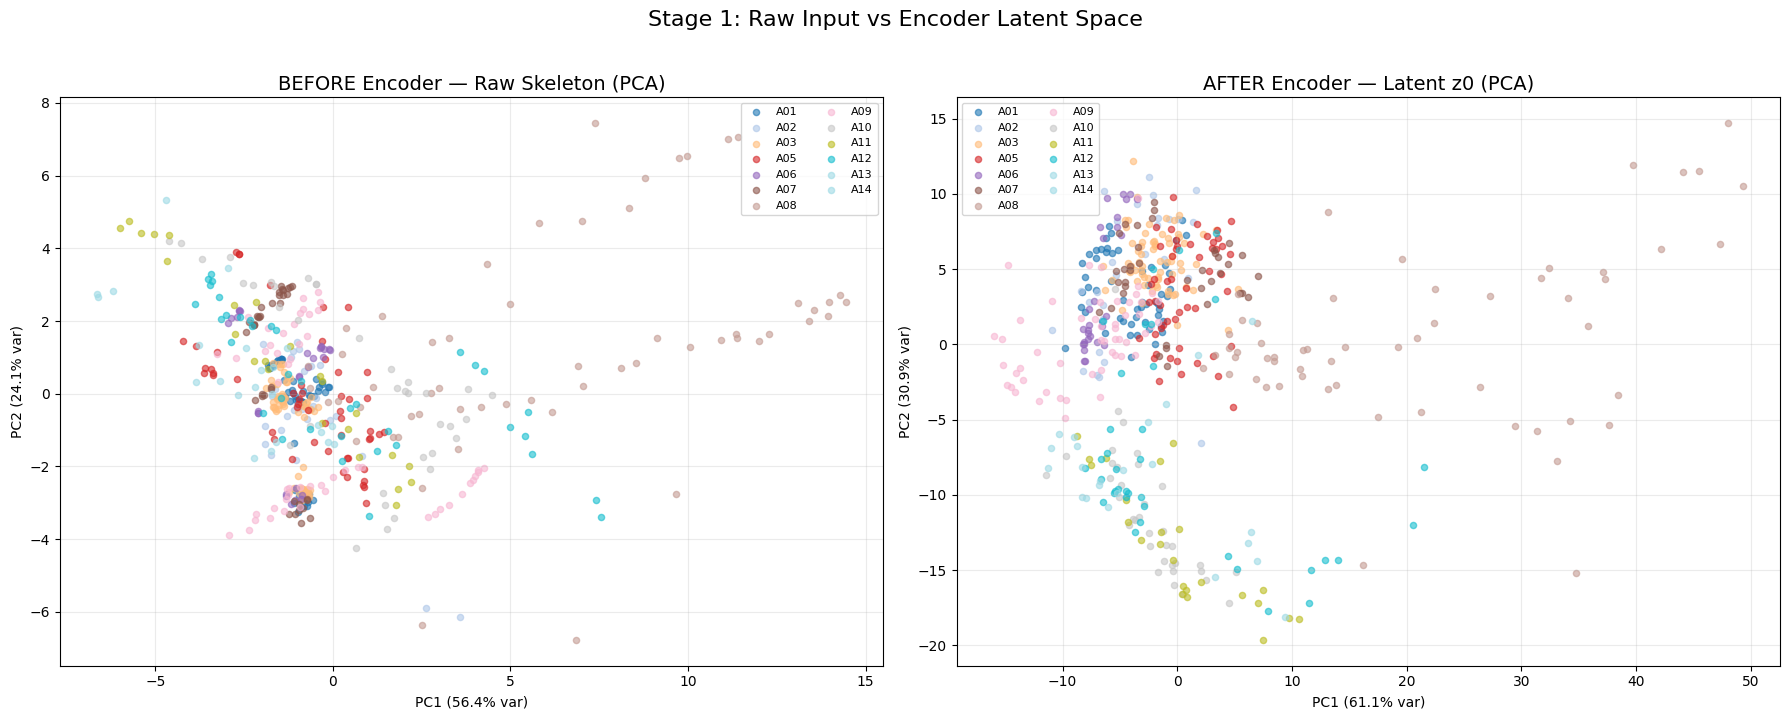

In [3]:
# ── PCA: Before vs After Encoder ──
num_classes = len(set(all_labels))
cmap = plt.cm.get_cmap("tab20", num_classes)

pca_raw = PCA(n_components=2, random_state=42)
pca_latent = PCA(n_components=2, random_state=42)
raw_2d = pca_raw.fit_transform(all_raw)
latent_2d = pca_latent.fit_transform(all_latent)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Before encoder (raw skeleton)
ax = axes[0]
for cid in sorted(set(all_labels)):
    mask = all_labels == cid
    ax.scatter(raw_2d[mask, 0], raw_2d[mask, 1], s=20, alpha=0.6, color=cmap(cid), label=f"A{cid+1:02d}")
ax.set_title("BEFORE Encoder — Raw Skeleton (PCA)", fontsize=14)
ax.set_xlabel(f"PC1 ({pca_raw.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca_raw.explained_variance_ratio_[1]*100:.1f}% var)")
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8, loc="best")

# Right: After encoder (latent z0)
ax = axes[1]
for cid in sorted(set(all_labels)):
    mask = all_labels == cid
    ax.scatter(latent_2d[mask, 0], latent_2d[mask, 1], s=20, alpha=0.6, color=cmap(cid), label=f"A{cid+1:02d}")
ax.set_title("AFTER Encoder — Latent z0 (PCA)", fontsize=14)
ax.set_xlabel(f"PC1 ({pca_latent.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca_latent.explained_variance_ratio_[1]*100:.1f}% var)")
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8, loc="best")

fig.suptitle("Stage 1: Raw Input vs Encoder Latent Space", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Computing t-SNE (may take a minute)...


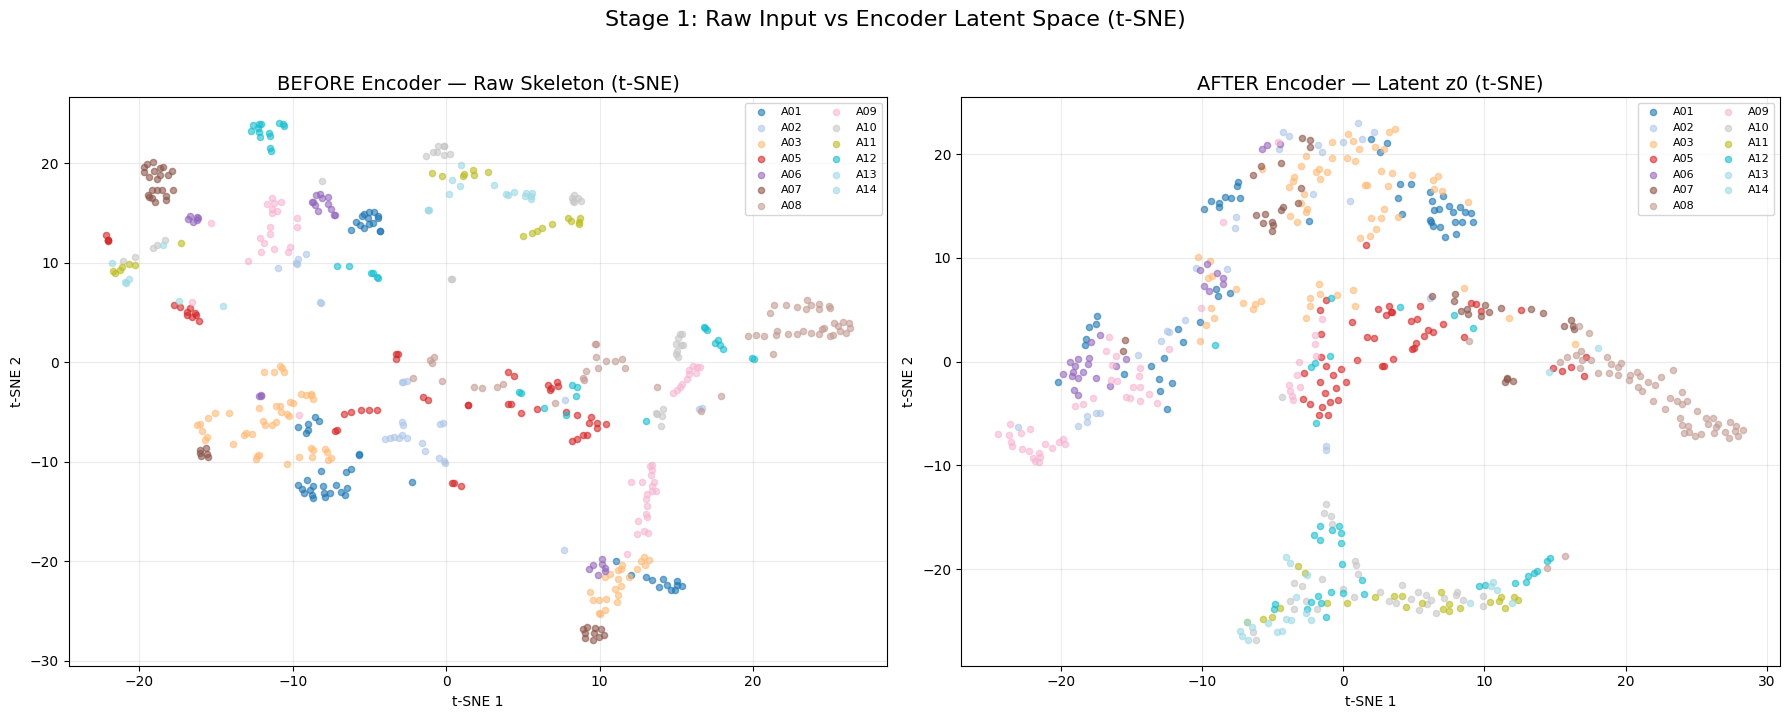

In [4]:
# ── t-SNE: Before vs After Encoder ──
print("Computing t-SNE (may take a minute)...")
tsne_raw = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto")
tsne_latent = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto")
raw_tsne = tsne_raw.fit_transform(all_raw)
latent_tsne = tsne_latent.fit_transform(all_latent)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for cid in sorted(set(all_labels)):
    mask = all_labels == cid
    ax.scatter(raw_tsne[mask, 0], raw_tsne[mask, 1], s=20, alpha=0.6, color=cmap(cid), label=f"A{cid+1:02d}")
ax.set_title("BEFORE Encoder — Raw Skeleton (t-SNE)", fontsize=14)
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8, loc="best")

ax = axes[1]
for cid in sorted(set(all_labels)):
    mask = all_labels == cid
    ax.scatter(latent_tsne[mask, 0], latent_tsne[mask, 1], s=20, alpha=0.6, color=cmap(cid), label=f"A{cid+1:02d}")
ax.set_title("AFTER Encoder — Latent z0 (t-SNE)", fontsize=14)
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8, loc="best")

fig.suptitle("Stage 1: Raw Input vs Encoder Latent Space (t-SNE)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

/home/qsw26/miniconda3/envs/smartfall_env_3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


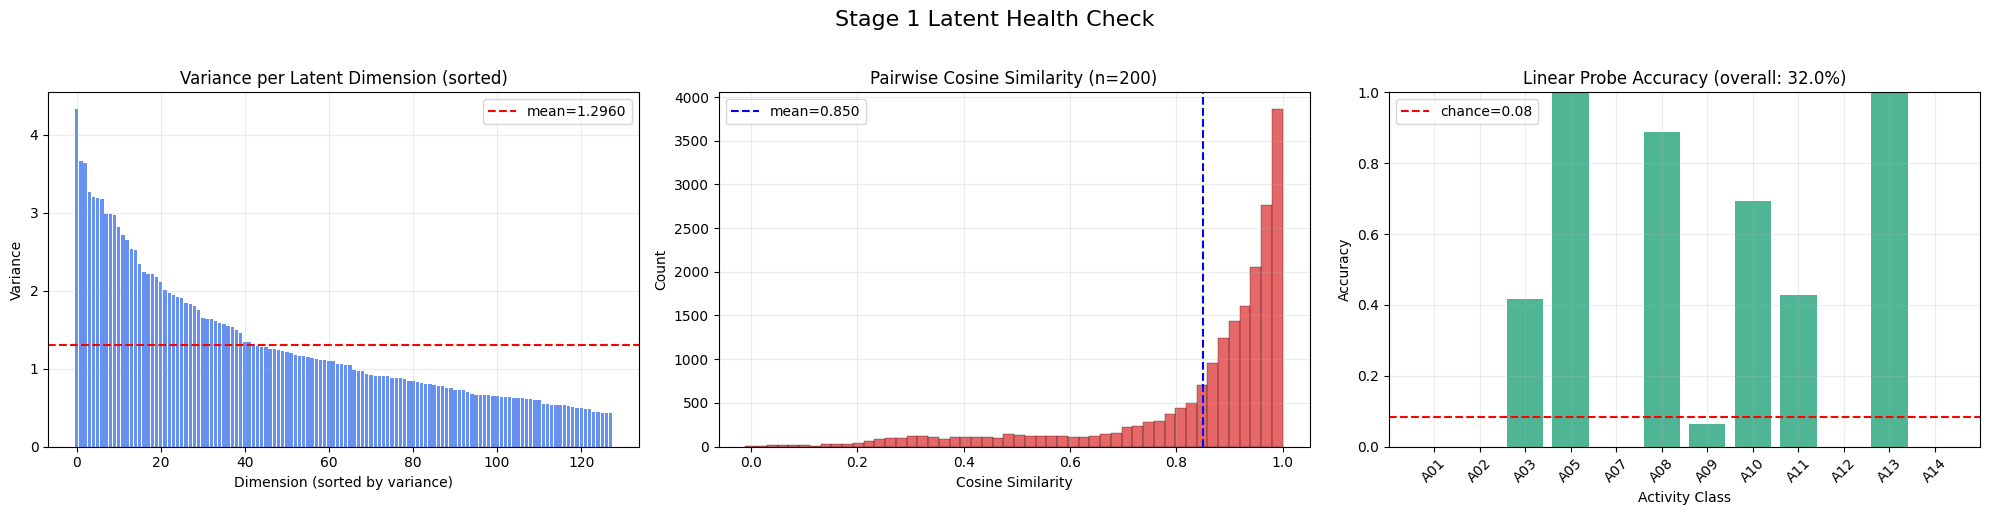


LATENT HEALTH SUMMARY
Latent std (overall):     3.4069  OK
Cosine sim (mean):        0.8504  OK
Active dims (var>0.01):   128/128  OK
Linear probe accuracy:    32.0%  WARNING: low discriminability


In [5]:
# ── Latent Health Check ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Variance per latent dimension — should be spread out, not concentrated
var_per_dim = all_latent.var(axis=0)  # [D]
axes[0].bar(range(len(var_per_dim)), np.sort(var_per_dim)[::-1], color="#2563eb", alpha=0.7)
axes[0].set_title("Variance per Latent Dimension (sorted)", fontsize=12)
axes[0].set_xlabel("Dimension (sorted by variance)")
axes[0].set_ylabel("Variance")
axes[0].axhline(y=var_per_dim.mean(), color="red", linestyle="--", label=f"mean={var_per_dim.mean():.4f}")
axes[0].legend()
axes[0].grid(alpha=0.25)

# 2. Pairwise cosine similarity — should NOT be all ~1.0
from sklearn.metrics.pairwise import cosine_similarity
n_check = min(200, len(all_latent))
cos_sim = cosine_similarity(all_latent[:n_check])
# Get upper triangle (exclude diagonal)
triu_idx = np.triu_indices(n_check, k=1)
cos_vals = cos_sim[triu_idx]
axes[1].hist(cos_vals, bins=50, color="#dc2626", alpha=0.7, edgecolor="black", linewidth=0.3)
axes[1].set_title(f"Pairwise Cosine Similarity (n={n_check})", fontsize=12)
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_ylabel("Count")
axes[1].axvline(x=cos_vals.mean(), color="blue", linestyle="--", label=f"mean={cos_vals.mean():.3f}")
axes[1].legend()
axes[1].grid(alpha=0.25)

# 3. Per-class accuracy from latent classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
# Quick linear probe
n_train = int(0.7 * len(all_latent))
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(all_latent[:n_train], all_labels[:n_train])
preds = clf.predict(all_latent[n_train:])
true = all_labels[n_train:]
unique_classes = sorted(set(true))
per_class_acc = []
for c in unique_classes:
    mask = true == c
    if mask.sum() > 0:
        per_class_acc.append((preds[mask] == true[mask]).mean())
    else:
        per_class_acc.append(0)
bars = axes[2].bar([f"A{c+1:02d}" for c in unique_classes], per_class_acc, color="#059669", alpha=0.7)
axes[2].set_title(f"Linear Probe Accuracy (overall: {(preds==true).mean()*100:.1f}%)", fontsize=12)
axes[2].set_xlabel("Activity Class")
axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0, 1)
axes[2].axhline(y=1/len(unique_classes), color="red", linestyle="--", label=f"chance={1/len(unique_classes):.2f}")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()
axes[2].grid(alpha=0.25)

fig.suptitle("Stage 1 Latent Health Check", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'='*50}")
print(f"LATENT HEALTH SUMMARY")
print(f"{'='*50}")
print(f"Latent std (overall):     {all_latent.std():.4f}  {'OK' if all_latent.std() > 0.1 else 'WARNING: possible collapse'}")
print(f"Cosine sim (mean):        {cos_vals.mean():.4f}  {'WARNING: near collapse' if cos_vals.mean() > 0.95 else 'OK' if cos_vals.mean() < 0.9 else 'BORDERLINE'}")
print(f"Active dims (var>0.01):   {(var_per_dim > 0.01).sum()}/{len(var_per_dim)}  {'OK' if (var_per_dim > 0.01).sum() > len(var_per_dim)*0.5 else 'WARNING: many dead dims'}")
print(f"Linear probe accuracy:    {(preds==true).mean()*100:.1f}%  {'OK' if (preds==true).mean() > 0.4 else 'WARNING: low discriminability'}")
print(f"{'='*50}")

In [6]:
!python probe_compare.py \
  --stage1_ckpt /home/qsw26/smartfall/gait_loss/ldm_with_loss/new_checkpoints/stage1_gcnn_changed_edits_withreport/stage1_best.pt \
  --stage2_ckpt /home/qsw26/smartfall/gait_loss/ldm_with_loss/new_checkpoints/stage2_gcnn_changed_edits_withreport/stage2_best.pt \
  --skeleton_folder /home/qsw26/smartfall/gait_loss/filtered_skeleton_data \
  --hip_folder /home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/phone \
  --wrist_folder /home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/watch \
  --latent_dim 128 \
  --imu_graph_type multiscale \
  --subject_wise_split \
  --val_frac 0.2 \
  --batch_size 32 \
  --epochs 50 \
  --pca_components 64 \
  --device cpu \
  --out_dir /home/qsw26/smartfall/gait_loss/ldm_with_loss/outputs/compare_probe


Loading Stage-1: /home/qsw26/smartfall/gait_loss/ldm_with_loss/new_checkpoints/stage1_gcnn_changed_edits_withreport/stage1_best.pt
/home/qsw26/smartfall/gait_loss/ldm_with_loss/diffusion_model/model_loader.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. 

In [16]:
!python diagnose_encoder_decoder_bridge.py \
  --stage1_ckpt new_checkpoints/stage1_gcnn_changed_edits_withreport_april3/stage1_best.pt \
  --stage2_ckpt new_checkpoints/stage2_gcnn_changed_edits_withreport_april3_regularized_0.5_simple_12_24f/stage2_best.pt \
  --stage3_ckpt new_checkpoints/stage3_gcnn_changed_edits_withreport_april3_regularized_0.5_simple1224f/stage3_best.pt \
  --skeleton_folder /home/qsw26/smartfall/gait_loss/filtered_skeleton_data \
  --hip_folder /home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/phone \
  --wrist_folder /home/qsw26/smartfall/gait_loss/SmartFallMM-Dataset/young/accelerometer/watch \
  --output_dir outputs/decoder_vs_diffusion_current \
  --num_samples 4 \
  --sample_steps 50 \
  --sampler ddpm \
  --sample_seed 0 \
  --imu_graph multiscale


2026-04-05 14:28:11.460263: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/qsw26/smartfall/gait_loss/ldm_with_loss/diffusion_model/model_loader.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlist

In [7]:
import pandas as pd 
import numpy as np

In [8]:
df = pd.read_csv("/home/qsw26/smartfall/gait_loss/ldm_with_loss/reports/stage3/stage3_gcnn_changed_edits_withreport/stage3/history.csv")

In [9]:
df.columns

Index(['epoch', 'train_loss_bone', 'train_loss_cls', 'train_loss_diff',
       'train_loss_gait', 'train_loss_latent', 'train_loss_motion',
       'train_loss_pose', 'train_loss_skate', 'train_loss_total',
       'train_loss_vel', 'val_loss_bone', 'val_loss_cls', 'val_loss_diff',
       'val_loss_gait', 'val_loss_latent', 'val_loss_motion', 'val_loss_pose',
       'val_loss_skate', 'val_loss_total', 'val_loss_vel'],
      dtype='object')

<Axes: >

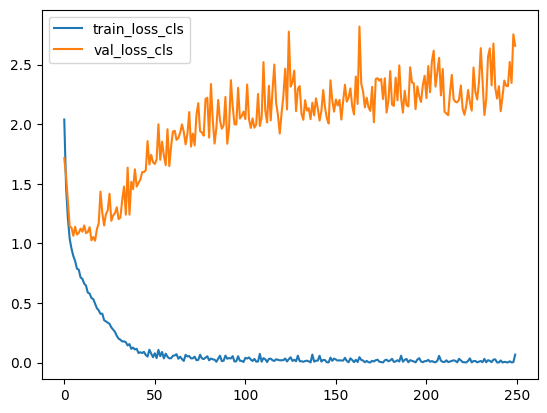

In [13]:
df[['train_loss_cls', 'val_loss_cls']].plot()